# 🤖 Model Training and Evaluation

## Project: House Price Prediction

### Objective

The objective of this notebook is to:

- Load the preprocessed dataset
- Train multiple Machine Learning models
- Evaluate model performance
- Compare models
- Select the best-performing model
- Save the trained model for deployment

The models used in this project are:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/processed/processed_housing.csv")

df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,7420,4,2,3,1,0,0,0,1,2,1,0,13300000
1,8960,4,4,4,1,0,0,0,1,3,0,0,12250000
2,9960,3,2,2,1,0,1,0,0,2,1,1,12250000
3,7500,4,2,2,1,0,1,0,1,3,1,0,12215000
4,7420,4,1,2,1,1,1,0,1,2,0,0,11410000


In [3]:
X = df.drop("price", axis=1)

y = df["price"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


In [5]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    }

In [6]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    lr_predictions
)

lr_results

{'Model': 'Linear Regression',
 'MAE': 979679.6912959905,
 'RMSE': np.float64(1331071.4167895105),
 'R² Score': 0.6494754192267804}

In [7]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_predictions
)

dt_results

{'Model': 'Decision Tree',
 'MAE': 1222399.0825688073,
 'RMSE': np.float64(1639566.2990811225),
 'R² Score': 0.4681689010023007}

In [8]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

rf_results

{'Model': 'Random Forest',
 'MAE': 1025289.6821100918,
 'RMSE': np.float64(1401263.0789821919),
 'R² Score': 0.6115321143409216}

In [9]:
results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results
])

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.796797e+05,1.331071e+06,0.649475
1,Decision Tree,1.222399e+06,1.639566e+06,0.468169
2,Random Forest,1.025290e+06,1.401263e+06,0.611532


In [10]:
best_model = results.sort_values(
    by="R² Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.796797e+05,1.331071e+06,0.649475
2,Random Forest,1.025290e+06,1.401263e+06,0.611532
1,Decision Tree,1.222399e+06,1.639566e+06,0.468169


In [11]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    lr_model,
    "../models/house_price_model.pkl"
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


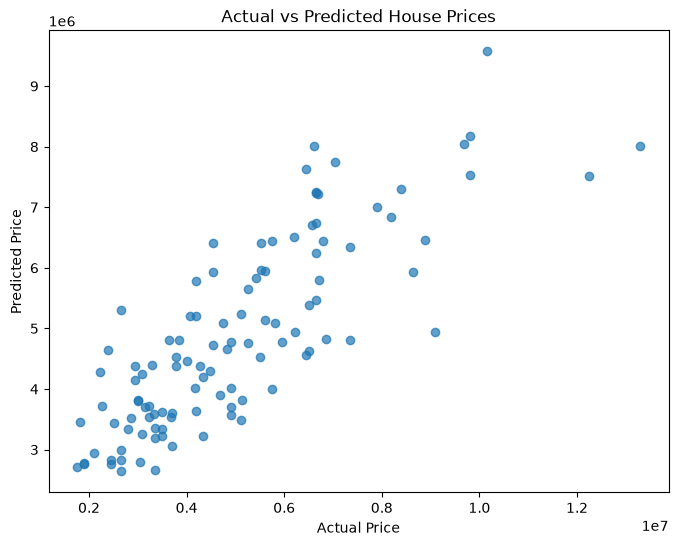

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.7
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

# 📌 Feature Importance

Linear Regression does not provide feature importance in the same way as tree-based models.

Instead, the learned coefficients can be inspected to understand the direction and magnitude of each feature's influence on the predicted house price.

For tree-based models such as Random Forest, feature importance values are available through the `feature_importances_` attribute.

# ✅ Conclusion

Three regression models were trained and evaluated.

Model comparison showed:

- Linear Regression achieved the highest R² Score.
- Decision Tree showed lower performance.
- Random Forest performed well but did not outperform Linear Regression.

Therefore, **Linear Regression** was selected as the final model and saved for deployment in the Streamlit application.